<a href="https://colab.research.google.com/github/roziyoussouf8-wq/programmation/blob/main/monte_carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Simulation de Monte Carlo Bayésienne : Estimer le Biais d'une Pièce**

Dans cet exemple, nous voulons estimer la probabilité d'obtenir "face" (appelons-la `theta`) pour une pièce. Nous utiliserons une approche bayésienne :

1.  **Distribution A Priori** : Notre croyance initiale concernant `theta` avant d'observer des données. Un choix courant pour les probabilités est la distribution Beta.
2.  **Fonction de Vraisemblance** : La probabilité d'observer nos données, étant donné une valeur spécifique de `theta`.
3.  **Distribution A Posteriori** : Notre croyance mise à jour concernant `theta` après avoir observé les données.

Nous utiliserons l'échantillonnage de Monte Carlo pour approximer la distribution a posteriori.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Définir la Distribution A Priori
# Nous allons supposer une distribution a priori uniforme pour theta (probabilité de face) entre 0 et 1.
# Cela peut être représenté par une distribution Beta(1, 1).
alfa_prior = 1
beta_prior = 1

# 2. Simuler les Données Observées
# Supposons que nous lançons une pièce 100 fois et observons 60 faces.
n_flips = 100
n_heads = 60
n_tails = n_flips - n_heads

print(f"Données observées : {n_heads} faces sur {n_flips} lancers.")

Données observées : 60 faces sur 100 lancers.


### **Étapes de la Simulation de Monte Carlo**

Nous allons approximer la distribution a posteriori en utilisant une méthode de Monte Carlo simple :

1.  **Échantillonner à partir de la distribution a priori** : Générer de nombreuses valeurs possibles de `theta` à partir de notre distribution a priori.
2.  **Calculer la vraisemblance pour chaque échantillon** : Pour chaque `theta` échantillonné, calculer la probabilité d'observer nos données (60 faces en 100 lancers).
3.  **Pondérer les échantillons par la vraisemblance** : Les échantillons de `theta` qui conduisent à une vraisemblance plus élevée de nos données observées sont plus probables dans la distribution a posteriori.

Alternativement, pour les distributions a priori conjuguées simples (comme Beta-Binomiale), la distribution a posteriori est également une distribution Beta. Nous pouvons calculer directement les paramètres a posteriori. Ici, nous utiliserons une approche d'échantillonnage plus généralisable aux problèmes complexes où le calcul direct pourrait ne pas être possible (ce qui est le cas pour le MCMC).

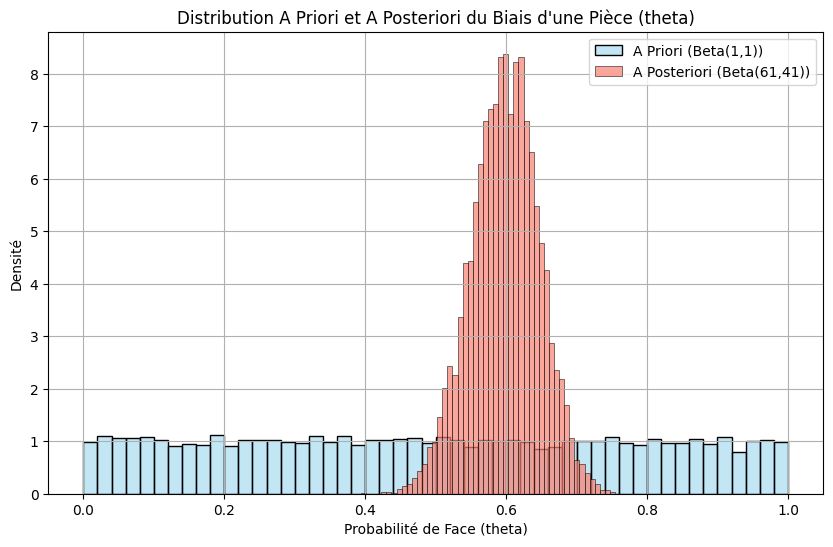


Moyenne A Posteriori de theta : 0.598
Écart-type A Posteriori de theta : 0.048
Intervalle de Crédibilité à 95% : (0.501, 0.689)


In [5]:
n_simulations = 10000 # Nombre d'échantillons Monte Carlo

# Simuler des échantillons à partir de la distribution Beta a priori
prior_samples = np.random.beta(alfa_prior, beta_prior, n_simulations)

# Calculer la vraisemblance pour chaque échantillon a priori
# La vraisemblance d'observer n_heads en n_flips étant donné theta est une probabilité binomiale.
# P(données | theta) = (n_flips choisir n_heads) * theta^n_heads * (1-theta)^n_tails
# Nous n'avons besoin que de la partie proportionnelle à theta pour l'échantillonnage, nous pouvons donc ignorer le coefficient binomial.
likelihoods = (prior_samples**n_heads) * ((1 - prior_samples)**n_tails)

# Pour obtenir des échantillons de la distribution a posteriori, nous pouvons utiliser l'échantillonnage par importance ou simplement pondérer les échantillons a priori par leurs vraisemblances.
# Pour la visualisation, nous pouvons simplement utiliser le fait que Beta est la distribution a priori conjuguée à la Binomiale.
# Paramètres a posteriori pour Beta-Binomiale : Beta(alfa_prior + n_heads, beta_prior + n_tails)
alfa_posterior = alfa_prior + n_heads
beta_posterior = beta_prior + n_tails

posterior_samples = np.random.beta(alfa_posterior, beta_posterior, n_simulations)

# Tracé
plt.figure(figsize=(10, 6))
sns.histplot(prior_samples, stat='density', color='skyblue', label='A Priori (Beta(1,1))', alpha=0.5, bins=50)
sns.histplot(posterior_samples, stat='density', color='salmon', label=f'A Posteriori (Beta({alfa_posterior},{beta_posterior}))', alpha=0.7, bins=50)
plt.title("Distribution A Priori et A Posteriori du Biais d'une Pièce (theta)")
plt.xlabel('Probabilité de Face (theta)')
plt.ylabel('Densité')
plt.legend()
plt.grid(True)
plt.show()

# Calculer les statistiques récapitulatives pour la distribution a posteriori
posterior_mean = np.mean(posterior_samples)
posterior_std = np.std(posterior_samples)

print(f"\nMoyenne A Posteriori de theta : {posterior_mean:.3f}")
print(f"Écart-type A Posteriori de theta : {posterior_std:.3f}")
print(f"Intervalle de Crédibilité à 95% : ({np.percentile(posterior_samples, 2.5):.3f}, {np.percentile(posterior_samples, 97.5):.3f})")

Cet exemple montre comment les données observées déplacent notre croyance (la distribution a posteriori) de la distribution a priori uniforme vers une valeur de `theta` plus proche de notre proportion observée de faces (60/100 = 0.6).

Pour des modèles plus complexes, surtout lorsque la distribution a posteriori ne peut pas être calculée directement, les méthodes de Monte Carlo par chaînes de Markov (MCMC), implémentées dans des bibliothèques comme `PyMC` ou `Stan`, sont utilisées pour échantillonner directement à partir de la distribution a posteriori.